# 03 · Data preprocessing and feature engineering

**SkillPath** (IT3051 Fundamentals of Data Mining, group KND_12)

Stage 4. This notebook runs the preprocessing step by step and shows the evidence
for each decision. The code itself lives in the `skillpath` package
(`src/skillpath/`), so that the **same** code is used by the modelling notebooks
and by the web backend. `scripts/build_dataset.py` runs everything in one go and
writes the outputs listed at the end.

Order of operations (the order is what prevents leakage):

1. **Deterministic row cleaning**: fixed rules, nothing learned from the data
2. **Cohort rules** and the **stratified train/test split** (frozen by ResponseId)
3. **Learned preprocessing** (vocabularies, imputation values, scaling) fitted on
   the training split only, inside one scikit-learn pipeline
4. **Supporting datasets** for AI exposure, personas and salary, built without
   test-set respondents

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import chi2, f_classif

from skillpath import config as C
from skillpath import viz
from skillpath import cleaning, cohorts
from skillpath.data import load_raw
from skillpath.split import make_split, load_split
from skillpath.pipeline import build_preprocessor, column_step, model_input_columns, feature_group

viz.setup()
pd.set_option("display.max_colwidth", 100)
raw = load_raw()
print(f"raw: {raw.shape[0]:,} x {raw.shape[1]}")

raw: 49,123 x 170


## 1. Deterministic row cleaning

### 1.1 Near-empty, duplicate and straight-lined responses

In [2]:
clean, r1 = cleaning.drop_near_empty(raw)
clean, r2 = cleaning.drop_exact_duplicates(clean)
clean, r2b = cleaning.drop_straightliners(clean)
pd.DataFrame([r1, r2, r2b]).drop(columns="hits_per_block")

,rule,rows_before,rows_removed,rows_after
0,near-empty responses (<= 10 answered fields),49123,5794,43329
1,exact duplicate responses (all fields except ResponseId),43329,0,43329
2,straight-lining: ticked >= 90% of the options in any technology list,43329,87,43242


### 1.2 Invalid experience values

* blank `WorkExp` with answered `YearsCode` means **0 years** (survey instruction)
* values impossible for the age band become missing (imputed later on train data)
* `WorkExp > YearsCode` is kept (career changers)

In [3]:
before = clean[["YearsCode", "WorkExp"]].copy()
clean, r3 = cleaning.clean_experience(clean)
pd.Series(r3, name="rows").to_frame()

,rows
WorkExp blank set to 0 (survey instruction),2919
YearsCode impossible for age band -> NaN,73
WorkExp impossible for age band -> NaN,100
WorkExp > YearsCode kept (career changers),3446


In [4]:
print("before cleaning:")
print(before.describe().round(1).T[["count", "min", "50%", "max"]].to_string())
print("\nafter cleaning:")
print(clean[["YearsCode", "WorkExp"]].describe().round(1).T[["count", "min", "50%", "max"]].to_string())

before cleaning:
             count  min   50%    max
YearsCode  42400.0  1.0  14.0  100.0
WorkExp    39837.0  1.0  11.0  100.0

after cleaning:
             count  min   50%   max
YearsCode  42327.0  1.0  14.0  75.0
WorkExp    42656.0  0.0  10.0  66.0


These rules use no statistics from the data (only the survey instruction and the
age bands), so applying them to all rows before the split cannot leak test
information.

## 2. Cohort and train/test split

In [5]:
role, attrition = cohorts.build_role_cohort(clean, raw_rows=len(raw))
attrition

,step,records
0,Raw public results file,49123
1,"Remove near-empty, duplicate and straight-lined responses",43242
2,"Keep a specific developer role (drop missing DevType, Student, Retired, Other)",38036
3,Keep skill-defined technical roles (drop management/seniority/non-technical),31406
4,Keep respondents who answered the main technology question,23072


In [6]:
split = make_split(role)
saved = load_split()
print("split reproduced exactly from the saved file:", split.equals(saved))
role = role.merge(split, on=C.ID_COL)
train, test = role[role.split == "train"].reset_index(drop=True), role[role.split == "test"].reset_index(drop=True)
print(f"train {len(train):,} ({len(train)/len(role):.0%})   test {len(test):,} ({len(test)/len(role):.0%})")

split reproduced exactly from the saved file: True
train 18,457 (80%)   test 4,615 (20%)


**Target.** The label is the specific job role (`JobRole`, 20 classes); the role
family is derived from it. Stratifying on the job role therefore also keeps the
family proportions equal in train and test.

**Why 80/20 and stratified?** With 23,072 respondents, 20% gives a 4,615-row test
set in which even the smallest job role (UX / UI Designer) has 12 examples, while
the training set keeps 18,457 rows for 5-fold cross-validation. Stratifying on the
job role keeps every class in the same proportion in both parts (checked below).
`random_state = 42` makes the split reproducible, and the IDs are saved to
`data/processed/split_ids.csv`.

In [7]:
strat = pd.DataFrame({
    "train %": train[C.TARGET_JOB].value_counts(normalize=True) * 100,
    "test %": test[C.TARGET_JOB].value_counts(normalize=True) * 100,
    "test n": test[C.TARGET_JOB].value_counts(),
}).round(2)
strat["difference"] = (strat["train %"] - strat["test %"]).abs().round(2)
strat.insert(0, "family", strat.index.map(C.ROLE_FAMILY))
strat.index = [C.JOB_ROLE_LABEL[i] for i in strat.index]
print("largest proportion difference (percentage points):", strat["difference"].max())
strat

largest proportion difference (percentage points): 0.02


,family,train %,test %,test n,difference
Full-stack Developer,Full-stack,39.44,39.44,1820,0.00
Back-end Developer,Backend,20.32,20.30,937,0.02
Desktop / Enterprise Developer,Desktop/Enterprise,6.43,6.44,297,0.01
Front-end Developer,Frontend,6.07,6.07,280,0.00
Embedded Developer,Embedded/Systems,4.18,4.18,193,0.00
Mobile Developer,Mobile,4.00,4.01,185,0.01
DevOps Engineer,DevOps/Cloud,3.49,3.49,161,0.00
Data Engineer,Data Eng,2.44,2.45,113,0.01
AI / ML Engineer,Data Sci/ML,1.89,1.89,87,0.00
Data Scientist,Data Sci/ML,1.89,1.89,87,0.00


## 3. The preprocessing pipeline

One `ColumnTransformer` with five branches, followed by a zero-variance filter
that drops any column that is constant in the training data. It is **fitted on
the training split only**. In Stage 6-7 it is wrapped with each model in a single sklearn `Pipeline`,
so during cross-validation it is refitted inside every fold as well.

| Branch | Input columns | Steps | Why |
|---|---|---|---|
| tech | 14 technology lists + 6 gate questions | multi-hot, rare to `OTHER`, log1p breadth, `unknown` flag, `want_new_count` | multi-select answers; true zero vs unknown; rare options unreliable |
| exp | YearsCode, WorkExp | log1p, `CareerChanger`, median impute + indicator, standard scale | right-skewed years; gaps after cleaning |
| ord | EdLevel, AISelect, AIAgents, AIAcc, AISent | fixed semantic order to integers, median impute + indicator, standard scale | ordered answer scales keep their order |
| region | Country | Country to 13 regions, "Missing" category, one-hot | 150+ sparse countries |
| nom | LearnCodeAI | "Missing" category, one-hot (unknown ignored) | unordered categories |

The optional **context** set adds OrgSize (ordinal) and Industry, RemoteWork and
ICorPM (one-hot). These describe the current employer, which students using the
app do not have, so they are kept out of the default set and will be tested as a
Stage 7 experiment.

In [8]:
cols = model_input_columns("core")
prep = build_preprocessor("core")
prep

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columns', ...), ('drop_constant', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tech', ...), ('exp', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [9]:
Xtr = prep.fit_transform(train[cols])
Xte = prep.transform(test[cols])
names = prep.get_feature_names_out()
print(f"input columns: {len(cols)}   ->   output features: {Xtr.shape[1]}")
print(f"train matrix {Xtr.shape}, test matrix {Xte.shape}")
groups = pd.Series([feature_group(n) for n in names]).value_counts().rename("features")
groups.to_frame()

input columns: 29   ->   output features: 479
train matrix (18457, 479), test matrix (4615, 479)


,features
Language (want),45
Platform (want),45
Platform (have),44
Language (have),43
Database (want),33
Database (have),32
Webframe (want),31
Webframe (have),30
DevEnvs (want),30
DevEnvs (have),29


## 4. Missing values

In [10]:
na_before = train[cols].isna().mean().mul(100).round(1)
na_before = na_before[na_before > 0].sort_values(ascending=False)
print("missing in the raw input columns (training split, %):")
print(na_before.to_string())
print(f"\nmissing values in the transformed training matrix: {int(np.isnan(Xtr).sum())}")
print(f"missing values in the transformed test matrix:     {int(np.isnan(Xte).sum())}")

missing in the raw input columns (training split, %):
AIModelsWantToWorkWith    63.0
SOTagsWantToWorkWith      58.1
AIModelsHaveWorkedWith    49.1
SOTagsHaveWorkedWith      44.6
WebframeWantToWorkWith    42.7
PlatformWantToWorkWith    37.4
DatabaseWantToWorkWith    36.1
DevEnvsWantToWorkWith     35.0
WebframeHaveWorkedWith    25.8
PlatformHaveWorkedWith    21.9
DevEnvsHaveWorkedWith     17.8
DatabaseHaveWorkedWith    17.5
LanguageWantToWorkWith    14.5
AIModelsChoice             6.8
AIAgents                   5.0
DevEnvsChoice              4.2
WebframeChoice             3.5
PlatformChoice             3.5
AIAcc                      3.0
AISent                     2.7
AISelect                   2.4
DatabaseChoice             2.1
LanguageChoice             1.9
YearsCode                  0.9
WorkExp                    0.5
EdLevel                    0.2
LearnCodeAI                0.2

missing values in the transformed training matrix: 0
missing values in the transformed test matrix:     0


How each kind of gap is handled:

| Gap | Treatment | Reason |
|---|---|---|
| technology list empty, gate = No | all zeros, `unknown` = 0 | a real "uses none" |
| technology list empty otherwise | all zeros, `unknown` = 1 | cannot guess what someone uses; flag lets the model tell "none" from "not answered" |
| gate questions themselves | only used to build the flag | they are not features on their own |
| WorkExp blank | 0 (cleaning step) | survey instruction |
| YearsCode / WorkExp still missing | training median + indicator column | small (< 2%), indicator keeps the information that it was missing |
| ordinal answers missing or off-scale ("Other", "I don't know") | training median + indicator | keeps the row; indicator preserves "no answer" |
| Country / LearnCodeAI missing | explicit "Missing" category | missingness itself can be informative |

The imputation values below were learned from the training split only:

In [11]:
exp_imp = column_step(prep).named_transformers_["exp"].named_steps["impute"]
ord_imp = column_step(prep).named_transformers_["ord"].named_steps["impute"]
learned = pd.DataFrame({
    "feature": ["log_YearsCode", "log_WorkExp", "CareerChanger"] + [f"{c}_ord" for c in C.ORDINAL_FEATURES_CORE],
    "training median": list(exp_imp.statistics_) + list(ord_imp.statistics_),
})
learned["in original units"] = [
    f"{np.expm1(learned.loc[0, 'training median']):.0f} years", f"{np.expm1(learned.loc[1, 'training median']):.0f} years",
    "no", *[{v: k for k, v in reversed(list(C.ORDINAL_MAPS[c].items()))}.get(int(m), m)
            for c, m in zip(C.ORDINAL_FEATURES_CORE, ord_imp.statistics_)]]
learned

,feature,training median,in original units
0,log_YearsCode,2.772589,15 years
1,log_WorkExp,2.397895,10 years
2,CareerChanger,0.000000,no
3,EdLevel_ord,4.000000,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
4,AISelect_ord,3.000000,"Yes, I use AI tools weekly"
5,AIAgents_ord,1.000000,"No, but I plan to"
6,AIAcc_ord,2.000000,Neither trust nor distrust
7,AISent_ord,3.000000,Favorable


## 5. Rare technologies pooled into OTHER

The vocabulary is learned from the training split: a technology gets its own
column only when at least 0.5% of training respondents chose it
(0.005 x 18,457 = 92.3, so at least 93 people).

In [12]:
tech = column_step(prep).named_transformers_["tech"]
rows = []
for (block, kind), rare in tech.rare_.items():
    if rare:
        counts = tech.token_counts_[(block, kind)]
        rows.append({"block": block, "list": kind, "pooled into OTHER": ", ".join(f"{t} ({counts[t]})" for t in rare)})
print("kept technology columns:", sum(len(v) for v in tech.vocabulary_.values()))
pd.DataFrame(rows)

kept technology columns: 403


,block,list,pooled into OTHER
0,Language,have,Mojo (38)
1,Database,have,Datomic (49)
2,Platform,have,Yandex Cloud (73)
3,Platform,want,Yandex Cloud (85)
4,AIModels,have,"Cohere: Command A (54), Reka (Flash 3 or other Reka models) (10)"
5,AIModels,want,"Cohere: Command A (65), Reka (Flash 3 or other Reka models) (50)"
6,SOTags,have,visionOS (79)


Only a few options are pooled, so almost no information is lost, and the `OTHER`
columns make the model robust to technologies it never saw (for example a new
framework typed into the web form). In blocks where no option was rare, the
`OTHER` column is always 0 in training, so the zero-variance filter drops it and an
unseen technology in that block is simply ignored.

## 6. One respondent before and after encoding

In [13]:
ex = train.iloc[[7]]
print("raw inputs:")
print(ex[cols].T.dropna().rename(columns={ex.index[0]: "value"}).to_string())
row = pd.Series(prep.transform(ex[cols])[0], index=names)
print(f"\nencoded: {int((row != 0).sum())} non-zero of {len(row)} features")
print(row[row != 0].round(3).to_string())

raw inputs:
                                                                                                      value
LanguageHaveWorkedWith                                                       HTML/CSS;JavaScript;Python;SQL
LanguageWantToWorkWith                                                                               Python
LanguageChoice                                                                                          Yes
DatabaseHaveWorkedWith                                                         MariaDB;MongoDB;MySQL;SQLite
DatabaseWantToWorkWith                                                                              MongoDB
DatabaseChoice                                                                                          Yes
PlatformChoice                                                                                           No
WebframeHaveWorkedWith                                                                   Django;Flask;React
WebframeWantToWo

## 7. Scaling

Only continuous and ordinal features are standardised (mean 0, SD 1). This is
needed by the distance and gradient based models planned in Stage 6 (logistic
regression, k-NN style methods) and is harmless for trees. The technology and
one-hot 0/1 columns are left as 0/1, which keeps them interpretable. (The missing
indicators and CareerChanger flag sit inside the scaled branches, so they are
scaled too; that does not change what they mean.)

The scaler statistics come from the training split, so the test split is close to,
but not exactly, mean 0 and SD 1. That small difference is the visible sign that
no test information was used.

In [14]:
scaled = [n for n in names if n.startswith(("exp__", "ord__"))]
idx = [list(names).index(n) for n in scaled]
scale_check = pd.DataFrame({
    "train mean": Xtr[:, idx].mean(0), "train sd": Xtr[:, idx].std(0),
    "test mean": Xte[:, idx].mean(0), "test sd": Xte[:, idx].std(0),
}, index=scaled).round(3)
scale_check

,train mean,train sd,test mean,test sd
exp__log_YearsCode,-0.0,1.0,0.042,1.004
exp__log_WorkExp,0.0,1.0,0.031,1.004
exp__CareerChanger,0.0,1.0,-0.017,0.970
exp__missingindicator_log_YearsCode,0.0,1.0,-0.007,0.964
exp__missingindicator_log_WorkExp,-0.0,1.0,0.007,1.048
exp__missingindicator_CareerChanger,0.0,1.0,-0.002,0.989
ord__EdLevel_ord,0.0,1.0,-0.015,1.013
ord__AISelect_ord,-0.0,1.0,-0.021,1.008
ord__AIAgents_ord,-0.0,1.0,-0.025,0.998
ord__AIAcc_ord,-0.0,1.0,-0.011,0.995


## 8. Feature engineering

| Engineered feature | Built from | Meaning / reason |
|---|---|---|
| `<block>_have_count`, `<block>_want_count` | technology lists | breadth of skills (log1p for skew) |
| `<block>_want_new_count` | want minus have | appetite to learn new tools in that area; the direction someone is moving |
| `<block>_<list>_unknown` | list + gate question | separates "not answered" from "uses none" |
| `<block>_<list>__OTHER` | rare technologies | rare-category grouping |
| `log_YearsCode`, `log_WorkExp` | experience | reduce right skew |
| `CareerChanger` | WorkExp > YearsCode | came from another field (24% of QA/Test, 3% of Backend in training data) |
| `Region` | Country | 13 UN M49 regions instead of 150+ sparse countries |
| `ExperienceBand` (salary only) | WorkExp | 0-2, 3-5, 6-10, 11-20, 20+ years for salary peer groups |
| `ai_exposure_now`, `ai_exposure_expected` (AI outlook only) | 13-task AI matrix | 0-100 index, mostly = 1, partially = 0.5 |

In [15]:
new_cols = [n for n in names if n.endswith(("_count", "_unknown", "__OTHER")) or "CareerChanger" in n]
eng = pd.DataFrame(Xtr[:, [list(names).index(n) for n in new_cols]], columns=new_cols)
print(f"engineered columns in the model matrix: {len(new_cols)}")
eng.describe().T[["mean", "min", "max"]].round(3).head(12)

engineered columns in the model matrix: 43


,mean,min,max
tech__Language_have__OTHER,0.002,0.000,1.000
tech__Language_have_count,1.845,0.693,3.638
tech__Language_want_count,1.412,0.000,3.761
tech__Language_want_unknown,0.145,0.000,1.000
tech__Database_have__OTHER,0.003,0.000,1.000
tech__Database_have_count,1.140,0.000,3.296
tech__Database_have_unknown,0.037,0.000,1.000
tech__Database_want_count,0.843,0.000,3.434
tech__Database_want_unknown,0.223,0.000,1.000
tech__Platform_have__OTHER,0.004,0.000,1.000


## 9. Feature selection

Three layers, from cheap to expensive:

1. **Scope** (done): only variables that serve the scenario and are available
   from a web user; target-derived, leaky and fairness-sensitive columns removed.
2. **Support and variance filter** (done, inside the pipeline): technologies below
   0.5% of training respondents are pooled into OTHER, and columns that are
   constant in the training data are dropped. The dropped ones are OTHER columns of
   blocks with no rare options and `Language_have_unknown` (always 0 because the
   cohort requires a language answer).
3. **Statistical relevance** (evidence now, decision in Stage 7): univariate tests
   on the training split show how many features carry signal. The final number of
   features (for example SelectKBest with k tuned) will be chosen **inside**
   cross-validation, because selecting on the whole training set and then
   cross-validating would leak.

In [16]:
ct_names = column_step(prep).get_feature_names_out()
kept = prep.named_steps["drop_constant"].get_support()
print(f"columns built: {len(ct_names)}   constant in training data, dropped: {(~kept).sum()}   kept: {kept.sum()}")
print(pd.Series(ct_names[~kept]).to_string(index=False))
var = Xtr.var(axis=0)
print(f"\nremaining near-constant features (variance < 0.001): {(var < 1e-3).sum()}")
print(pd.Series(var, index=names)[var < 1e-3].round(5).to_string())

columns built: 487   constant in training data, dropped: 8   kept: 479
tech__Language_have_unknown
 tech__Language_want__OTHER
 tech__Database_want__OTHER
 tech__Webframe_have__OTHER
 tech__Webframe_want__OTHER
  tech__DevEnvs_have__OTHER
  tech__DevEnvs_want__OTHER
   tech__SOTags_want__OTHER



remaining near-constant features (variance < 0.001): 1
region__Region_Missing    0.00054


In [17]:
nonneg = Xtr.min(axis=0) >= 0
chi, p_chi = chi2(Xtr[:, nonneg], train[C.TARGET_JOB])
F, p_f = f_classif(Xtr[:, ~nonneg], train[C.TARGET_JOB])
rel = pd.concat([
    pd.DataFrame({"feature": names[nonneg], "test": "chi2", "statistic": chi, "p": p_chi}),
    pd.DataFrame({"feature": names[~nonneg], "test": "ANOVA F", "statistic": F, "p": p_f}),
])
alpha = 0.01 / len(rel)  # Bonferroni correction for testing every feature
rel["significant"] = rel["p"] < alpha
print(f"features significant at Bonferroni-corrected alpha ({alpha:.1e}): "
      f"{rel['significant'].sum()} of {len(rel)}")
print(rel.groupby(rel["feature"].map(feature_group))["significant"].agg(["sum", "count"])
      .rename(columns={"sum": "significant", "count": "features"}).to_string())

features significant at Bonferroni-corrected alpha (2.1e-05): 431 of 479
                                significant  features
feature                                              
AIModels (have)                          17        18
AIModels (want)                          18        19
Database (have)                          30        32
Database (want)                          30        33
DevEnvs (have)                           26        29
DevEnvs (want)                           27        30
Experience                                6         6
Language (have)                          35        43
Language (want)                          40        45
Nominal (AI learning, context)            4         6
Ordinal (education, AI usage)             5        10
Platform (have)                          41        44
Platform (want)                          42        45
Region                                    8        13
SOTags (have)                            21        22
SOTags (w

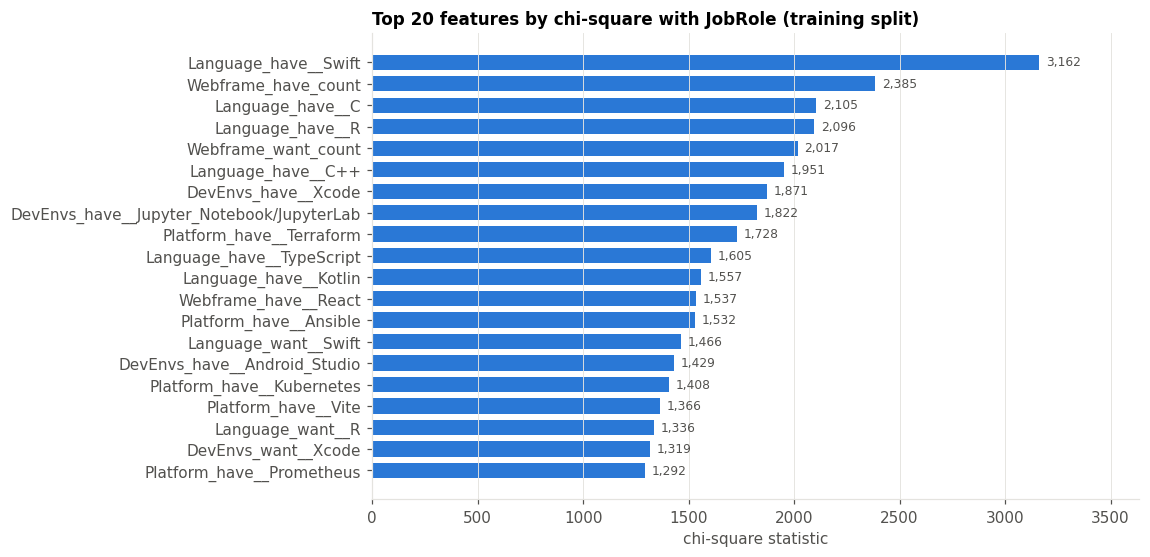

In [18]:
top = rel[rel.test == "chi2"].sort_values("statistic", ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 5.5))
viz.barh(ax, [f.replace("tech__", "") for f in top["feature"]], top["statistic"].round(0).tolist())
ax.set(title="Top 20 features by chi-square with JobRole (training split)", xlabel="chi-square statistic")
viz.save(fig, "03_chi2_top20")
plt.show()

Most features are individually related to the job role, and the strongest are the
expected technologies (JavaScript, Swift, HTML/CSS, C, the "no web framework" flag).
Features that are not significant on their own are **not** dropped yet: they can
still help in combination (for example a Kotlin + Android Studio pattern), and
dropping them now, outside cross-validation, would be a form of leakage.

**Stage 7 feature-selection experiments** (all inside CV): SelectKBest with k in
{100, 200, 300, all}; `min_frequency` in {0.25%, 0.5%, 1%}; with and without the
want lists; core vs core+context; dropping one of YearsCode/WorkExp.

## 10. Supporting datasets

These feed the AI outlook, persona clustering and salary benchmark. Every one of
them excludes the recommender's test respondents, so the tables the app shows are
never built from data used to evaluate the model.

In [19]:
report = json.loads((C.REPORTS_DIR / "build_report.json").read_text())
pd.DataFrame({
    "dataset": ["AI exposure (role cohort)", "AI persona inputs", "Salary reference"],
    "file": ["data/reference/ai_exposure_role_cohort.parquet", "data/reference/persona_inputs.parquet",
             "data/reference/salary_reference.parquet"],
    "rows": [report["ai_exposure"]["index_computed_train"], report["persona"]["after_excluding_role_test_ids"],
             report["salary"]["final_reference_rows"]],
    "note": ["train rows with >= 7 of 13 tasks rated (test rows kept but flagged by split)",
             "all 6 AI questions answered; AIComplex 'don't use / don't know' -> missing",
             "two-stage outlier rule fitted on these rows"],
})

,dataset,file,rows,note
0,AI exposure (role cohort),data/reference/ai_exposure_role_cohort.parquet,16538,train rows with >= 7 of 13 tasks rated (test rows kept but flagged by split)
1,AI persona inputs,data/reference/persona_inputs.parquet,26925,all 6 AI questions answered; AIComplex 'don't use / don't know' -> missing
2,Salary reference,data/reference/salary_reference.parquet,15545,two-stage outlier rule fitted on these rows


### 10.1 AI persona inputs

The six AI questions are ordinal scales and are encoded with the same fixed maps
(for example AIAgents: no and no plan = 0 up to daily = 5). They will be scaled
and clustered in the modelling stage (K-means / K-prototypes, silhouette score).

In [20]:
persona = pd.read_parquet(C.REFERENCE_DIR / "persona_inputs.parquet")
persona[[f + "_ord" for f in C.PERSONA_FEATURES]].describe().round(2).T[["count", "mean", "min", "max"]]

,count,mean,min,max
AISelect_ord,26925.0,2.74,0.0,4.0
AIAgents_ord,26925.0,1.76,0.0,5.0
AIAcc_ord,26925.0,1.69,0.0,4.0
AISent_ord,26925.0,2.51,0.0,4.0
AIComplex_ord,22377.0,1.70,0.0,4.0
AIAgentChange_ord,26925.0,0.68,0.0,2.0


### 10.2 Salary reference

In [21]:
pd.read_csv(C.REPORTS_DIR / "salary_reference_attrition.csv")

,step,records
0,Developer by profession,33542
1,Employed or self-employed,31212
2,Reported annual compensation,19443
3,Exclude recommender test-set respondents,16356
4,"Keep $1,000 to $1,000,000",15973
5,Drop |robust z| > 3.5 within country/region,15545


In [22]:
ref = pd.read_parquet(C.REFERENCE_DIR / "salary_reference.parquet")
print(ref.groupby("ExperienceBand", observed=True)[C.SALARY_COL].median().round(0)
      .reindex(C.EXPERIENCE_BAND_LABELS).rename("median USD").to_string())

ExperienceBand
0-2       34804.0
3-5       47932.0
6-10      75410.0
11-20     97452.0
20+      116015.0


## 11. Leakage prevention checklist

Each item below is checked by code, here and in `tests/test_preprocessing.py`.

In [23]:
test_ids = set(test[C.ID_COL])
checks = {
    "target / leaky columns are not model inputs": not (set(cols) & set(C.LEAKY_OR_EXCLUDED + [C.SALARY_COL])),
    "train and test respondents are disjoint": not (set(train[C.ID_COL]) & test_ids),
    "technology vocabulary learned from train only": build_preprocessor().fit(train[cols])
        .named_steps["columns"].named_transformers_["tech"].vocabulary_ == tech.vocabulary_,
    "no test respondents in salary reference": not (set(ref[C.ID_COL]) & test_ids),
    "no test respondents in persona inputs": not (set(persona[C.ID_COL]) & test_ids),
    "no missing values after preprocessing": not np.isnan(Xtr).any() and not np.isnan(Xte).any(),
    "Admired columns not used": not any("Admired" in c for c in cols),
    "Age not used as a feature": "Age" not in cols,
}
pd.Series(checks, name="passed").to_frame()

,passed
target / leaky columns are not model inputs,True
train and test respondents are disjoint,True
technology vocabulary learned from train only,True
no test respondents in salary reference,True
no test respondents in persona inputs,True
no missing values after preprocessing,True
Admired columns not used,True
Age not used as a feature,True


## 12. Outputs and how the next stages use them

| File | Content |
|---|---|
| `data/processed/split_ids.csv` | frozen train/test assignment |
| `data/processed/train.parquet`, `test.parquet` | cleaned cohort rows with raw model inputs + JobRole + RoleFamily |
| `data/processed/features_core_{train,test}.parquet` | transformed matrices (479 features) for quick exploration |
| `artifacts/preprocessor_core.joblib` | the preprocessor fitted on the training split |
| `artifacts/feature_names_core.json` | output feature names |
| `artifacts/options.json` | every valid input value for the web form |
| `artifacts/salary_outlier_rule.json` | country/region medians and MADs for the salary rule |
| `data/reference/*.parquet` | AI exposure, persona and salary datasets |
| `reports/build_report.json`, `reports/*_attrition.csv` | counts for the report |

**For modelling (Stage 6-7)** use the raw training rows with the unfitted
preprocessor inside a pipeline, so each CV fold refits it:

```python
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from skillpath.pipeline import build_preprocessor, model_input_columns

train = pd.read_parquet("data/processed/train.parquet")
pipe = Pipeline([("prep", build_preprocessor()), ("clf", LogisticRegression(max_iter=2000))])
cross_validate(pipe, train[model_input_columns()], train["JobRole"],
               cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="f1_macro")
```

## 13. From job-role probabilities to the recommendation

The classifier (Stage 6-7) returns one probability per job role. `skillpath.targets`
turns that into what the app shows: the top-3 job roles (with label, family and a
one-line description) and the family totals, where a family's probability is the
sum of its job roles. The mapping used:

In [24]:
from skillpath import targets

pd.DataFrame([{"job role": C.JOB_ROLE_LABEL[j], "family": f, "description": C.JOB_ROLE_DESCRIPTION[j]}
              for j, f in C.ROLE_FAMILY.items()]).sort_values(["family", "job role"]).reset_index(drop=True)

,job role,family,description
0,Back-end Developer,Backend,"Builds server-side logic, APIs, databases and integrations."
1,Data Engineer,Data Eng,Builds the pipelines and platforms that move and store data at scale.
2,Database Administrator / Engineer,Data Eng,"Designs, runs and tunes databases for reliability and performance."
3,AI / ML Engineer,Data Sci/ML,"Builds, trains and deploys machine learning and AI models."
4,AI Application Developer,Data Sci/ML,"Builds applications on top of AI models, LLMs and agents."
5,Applied Scientist,Data Sci/ML,Turns research methods into working models and products.
6,Data / Business Analyst,Data Sci/ML,Analyses data and reports insight to support business decisions.
7,Data Scientist,Data Sci/ML,Uses statistics and machine learning to find insight in data.
8,Desktop / Enterprise Developer,Desktop/Enterprise,Builds desktop software and large internal business systems.
9,Cloud Infrastructure Engineer,DevOps/Cloud,Designs and manages cloud platforms and infrastructure as code.


In [25]:
# Illustration only (made-up probabilities, not a model output): how a result is assembled.
demo = np.zeros(len(targets.JOB_ROLES))
for role, p_ in {"Data engineer": 0.30, "Data scientist": 0.18, "Developer, back-end": 0.14,
                 "AI/ML engineer": 0.12, "Database administrator or engineer": 0.06}.items():
    demo[targets.JOB_ROLES.index(role)] = p_
demo[demo == 0] = (1 - demo.sum()) / (demo == 0).sum()
print("top-3 job roles:")
for r in targets.top_k(demo, targets.JOB_ROLES):
    print(f"  {r['label']:<34} {r['family']:<13} {r['probability']:.2f}")
print("top-3 families (sum of their job roles):")
for r in targets.top_k_families(demo, targets.JOB_ROLES):
    print(f"  {r['family']:<13} {r['probability']:.2f}")

top-3 job roles:
  Data Engineer                      Data Eng      0.30
  Data Scientist                     Data Sci/ML   0.18
  Back-end Developer                 Backend       0.14
top-3 families (sum of their job roles):
  Data Eng      0.36
  Data Sci/ML   0.34
  Backend       0.14


## 14. Ready for the web app

The backend will receive a JSON profile from the form, convert it with
`profile_to_frame()` into one survey-format row and call the **same fitted
pipeline**. Below: a made-up Sri Lankan undergraduate who skipped the web framework
question, uses no databases, and typed a technology the model has never seen.

In [26]:
from skillpath.profile import profile_to_frame

profile = {
    "country": "Sri Lanka", "years_code": 3, "work_exp": 0,
    "ed_level": "Some college/university study without earning a degree",
    "tech": {
        "Language": {"have": ["Python", "SQL", "JavaScript"], "want": ["Go"]},
        "Database": {"none": True},
        "Platform": {"have": ["Docker", "SomeBrandNewTool"], "want": ["Kubernetes"]},
        "DevEnvs": {"have": ["Visual Studio Code", "Jupyter Notebook/JupyterLab"]},
    },
    "ai": {"AISelect": "Yes, I use AI tools daily", "AIAgents": "No, but I plan to",
           "AIAcc": "Somewhat trust", "AISent": "Favorable"},
}
x = pd.Series(prep.transform(profile_to_frame(profile)[cols])[0], index=names)
print("shape:", x.shape, " any missing:", bool(np.isnan(x).any()))
print(x[[n for n in names if n.startswith(("tech__Database_have", "tech__Webframe_have", "tech__Platform_have__OTHER",
                                           "region__"))] + ["exp__log_WorkExp"]][lambda s: s != 0].round(3).to_string())

shape: (479,)  any missing: False
tech__Platform_have__OTHER     1.000
tech__Webframe_have_unknown    1.000
region__Region_South Asia      1.000
exp__log_WorkExp              -2.729
